# Judge experiments notebook

## Motivation

When the circumstances obliged us to work with such metrics as Accuracy, Precision, Recall, Hallucination Rate, Reusability, all of us were confused by the question "How to evaluate the metrics on non-deterministic samples with no Q&A samples?". 
\
It's not the rocket science to evaluate the Accuracy = (TP+TN)/(TP+TN+FP+FN) and Precision = TP/(TP+FP) in the case of supervised learning with numeric data attributes (moreover, categorial attributes and even NLP tasks in the case of SUPERVISED learning are not unsolvable problems anymore). But let's take a look on our case. But what are the availabilities?
\
\
Entities to process:
* **Query** = the sentence written by the user to an Assistant. The sense of the question is Natural-language-based
* **Answer** = the LLM-generated text without tool-use (simple configuration), but with the retrieved context
* **Document** = the entity consisting of the text in the Telegram-chat and the files attached to text, but the files cannot be converted to the sense if we talk about ANY files (.xlsx, .docx, .ipynb, .jpg, .exe ... cannot be templated or retrieved in any available way)
\
\
Parameters of the cycle Request->Response->Validate
* **System_prompt** = our support for the generation quality (controlled)
* **LLM** = generator of the text (controlled model, but the ideal configuration price/quality is an undetermined question for this work)
* **Retriever** = the 'browser'; looks for the best documentation for the query (controlled count of the documents to retrieve, the size of the atomic document, the model to encode the documents)
* **Validator** = the result of this particular research

All the solutions for any evaluation system can be divided into 4 groups:
* Deterministic (code-based, algorithm):
    * Pros: reliable, reusable, predictable, fast, cheap
    * Cons: no edge cases processing and context question paraphrasing will be marked correctly. ( \
        Q: what was there on the meeting? \
        A: It is now in progress - lots of speakers are there, no information about the results! \
        We have no algorithm to proceed this edge case with 'no information' piece and 'now' when we speak about the past. Our team came out with an idea that all the \
        frameworks have some edge cases, which cause the accuracy drop
        )
* Human-based (every case is proceeded by a human):
    * Pros: reliable, the most explicable
    * Cons: expensive, slow, no automation available
    These solutions cannot be used (at least they are too expensive)
* LLM-as-judge
    * Pros: fast*, cheap*, reliable*, reusable, automatic, can work as well as a human in an enormous amount of tasks.
    * Cons: can be very expensive, non-deterministic algorithms, we need lots of compute (resources) for good inference and quality, non-local inference cannot garanty
    for data-security. \
    \
    *All the results depends on the configuration of the system, that`s why the quality of the eval correlate with the work we proceed during configuration. \
    \
    The LLM-as-judge solution is the Eval system in which we have a AI model (transformer-based pretrained LLM in 99.99% cases) to evaluate the answers of an Assistant.\
    We need to mark the QA samples (>20) with the quality mark by our own and choose the model, prompt, parameters to maximize the accuracy of this evaluation.
    \


As wee can see there is one good variant among the seen. We want to maximize the quality of the metric system, our inference is the testing system (not so many users will use the model and not so many tokens will be used -> not very expensive) that`s why we can put up with almost all the disadvantages. Therefore, we need to work out the Eval confuration of the judge for our testing-system. We will compare some different configurations on the generated and human-evaluated examples of the questions and answers and choose the best one.

## Problem statement

We are trying to solve the optimization task in non-deterministic task, let's think it to be probabilistic task. We need to postulate the target distribution and vary the distribution which we want to approximate the target with. The distance function $ \rho = \rho(D, \hat{D}) $ should be objective (the worse grader the further it should be).
\
The main statistic used in the industry as a agreement grade is *Kohen`s kappa*. We will use it to evaluate the graders and compare each other.

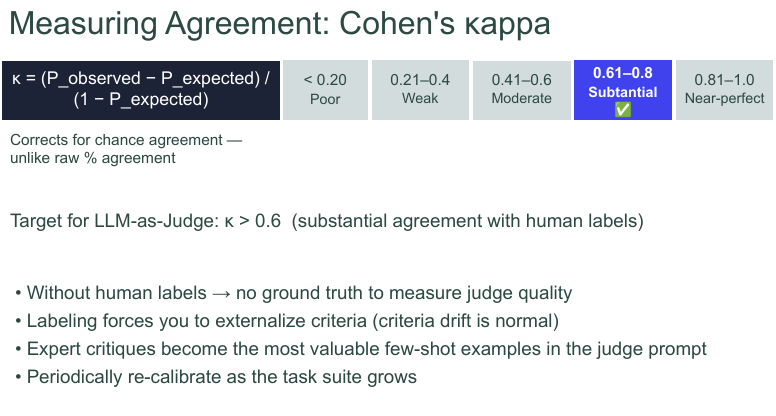

Now we will initialize the target grades for synthetic QA-sessions. In this research we will do our best to make judge Subtantial, but as the practice shows, this goal is to ambicious as a starting point. The system should be graded in inference to make this gain become true. Let's start with "good enough" grader.

## Marked synthetic data

### Chats

In [1]:
chat_123 = {
    1:"АДВОКАТ: Здравствуйте. Да, письмо видел. Давайте по порядку. Начнём с подрядчика – это срочнее, потому что там просрочка уже больше месяца.",
    2:"КЛИЕНТ: Согласен. Если коротко: в ноябре заключили договор на ремонт офиса, срок сдачи был 15 января. Сейчас 20 февраля, работы выполнены процентов на 40. Я им направил претензию по почте, но ответа нет.",
    3:"(*)КЛИЕНТ: Вот договор и фото того, что сделано.",
    4:"АДВОКАТ: Принял, посмотрел. Договор типовой, но пункт 5.4 о неустойке за каждый день просрочки очень выгодный для вас – 0,3% от стоимости работ. При цене договора в 960 тысяч это почти 3 тысячи в день.",
    5:"КЛИЕНТ: Я считал, получается около 105 тысяч за 35 дней. Это реально взыскать?",
    6:"АДВОКАТ: Да, сумма внушительная. Но по статье 333 ГК суд может снизить неустойку, если она явно несоразмерна. Обычно режут до двукратной ставки ЦБ, тогда может выйти около 55–65 тысяч. Но мы запросим полную сумму, это рычаг для переговоров.",
    7:"КЛИЕНТ: Меня сам ремонт больше волнует. Они могут вообще бросить объект. Как заставить доделать?",
    8:"АДВОКАТ: Здесь два пути. Первый – требовать исполнения через суд, но это долго. Второй – сейчас направить уведомление о расторжении договора и потребовать возврат неотработанного аванса. Вы платили аванс?",
    9:"КЛИЕНТ: Да, 400 тысяч, есть платёжка.",
    10:"(*)КЛИЕНТ: Платёжное поручение.",
    11:"АДВОКАТ: Отлично. Аванс 400 тыс. при общей цене 960 тыс. – это 42%. Неотработанная часть аванса примерно 400 – (960*40%) = 16 тысяч, но мы не про возврат аванса будем спорить, а о взыскании убытков и неустойки. Здесь надо аккуратно посчитать убытки: стоимость устранения недостатков и завершения ремонта.",
    12:"КЛИЕНТ: Я понял. Тогда давайте готовить уведомление о расторжении. Пока не подаём в суд?",
    13:"АДВОКАТ: Да, сначала досудебное урегулирование. Я подготовлю проект сегодня до 18:00. Это бесплатно в рамках первой консультации, как договаривались.",
    14:"КЛИЕНТ: Спасибо. И ещё: у них на объекте остался инструмент. Мы можем его удерживать?",
    15:"АДВОКАТ: Нет, это незаконно. Вы должны обеспечить доступ для вывоза имущества, иначе вам могут вменить самоуправство. Просто зафиксируйте опись с фото.",
    16:"КЛИЕНТ: Ладно, тогда без самодеятельности. Теперь по трудовому спору. Я вам скидывал детали: сотрудник жалуется, что мы не оплатили сверхурочные за декабрь.",
    17:"АДВОКАТ: Да, помню. Вы говорили, что работали по сменному графику, и переработка была в пределах 120 часов в год, это законно. Но сотрудник утверждает, что за декабрь переработал 45 часов сверх нормы.",
    18:"КЛИЕНТ: Именно. Он принёс свою таблицу учёта. Я её вам пересылал.",
    19:"(*)КЛИЕНТ: Табель сотрудника.",
    20:"АДВОКАТ: Видел. Там нет подписей, составляет сам работник, доказательная сила слабая. Но у нас есть ваш табель, подписанный мастером. В нём переработка 28 часов – это в пределах допустимого по ст. 99 ТК, и она уже оплачена по полуторному тарифу за первые два часа и двойному за остальные. Я бы предложил дождаться его жалобы в инспекцию, если она вообще будет.",
    21:"КЛИЕНТ: А если он пойдёт в суд, какие шансы?",
    22:"АДВОКАТ: При наличии вашего табеля с подписью – высокие шансы выиграть. Но нужно проверить, корректно ли составлены дополнительные соглашения к трудовому договору о ненормированном дне. У вас они есть?",
    23:"КЛИЕНТ: Да, я ещё в ноябре подписал приказ о ненормированном дне для трёх должностей, в том числе для этого сотрудника.",
    24:"АДВОКАТ: Это сильный аргумент. Ненормированный день компенсируется не сверхурочными, а дополнительным отпуском. Если приказ оформлен правильно, то требования сотрудника безосновательны.",
    25:"КЛИЕНТ: Отлично, гора с плеч. Давайте теперь по деньгам сориентируемся. Сколько будет стоить взыскание по подрядчику «под ключ»?",
    26:"АДВОКАТ: Если дойдём до суда, то госпошлина при цене иска около 600 тыс. (неустойка + убытки) составит примерно 9200 рублей. Моя работа: составление иска – 18 000, представительство в двух заседаниях – 30 000. Итого около 57 тысяч плюс расходы на экспертизу, если понадобится. Но мы постараемся решить в претензионном порядке, тогда только 18 000 за документы.",
    27:"КЛИЕНТ: Принято. Я планирую быть в городе 5 и 6 марта. Сможем встретиться, чтобы подписать доверенность и обсудить стратегию?",
    28:"АДВОКАТ: 5 марта в 11:00 у меня окно. Могу забронировать переговорку. Вас устроит?",
    29:"КЛИЕНТ: Да, отлично. Кстати, как ваши выходные? Вы говорили, что собирались за город.",
    30:"АДВОКАТ: Спасибо, всё удалось. Немного развеялся, теперь снова в режим. По вашим делам: до встречи я подготовлю проект уведомления подрядчику и анализ трудового договора сотрудника.",
    31:"КЛИЕНТ: Супер. Тогда до 5 марта.",
    32:"АДВОКАТ: Договорились. Если будут срочные вопросы – пишите в мессенджер. Документы загружу в облако, пришлю ссылку."
}
chat_124 = {
    1: "КЛИЕНТ: Добрый день. Я вам писала на почту о намерении расторгнуть брак. Муж согласен, но по имуществу и детям начинаются сложности.",
    2: "АДВОКАТ: Здравствуйте. Да, изучил ваше письмо. Давайте по порядку. Брак зарегистрирован в 2015 году, двое детей, верно?",
    3: "КЛИЕНТ: Да, сын 2016 года и дочь 2019. Я хочу, чтобы дети жили со мной, но муж угрожает, что будет требовать равного проживания.",
    4: "АДВОКАТ: Приоритет обычно у матери, особенно если дети малолетние. Но нужно подтвердить вашу состоятельность. Вы работаете?",
    5: "КЛИЕНТ: Да, официально, зарплата 85 тысяч. Муж получает около 120, но часть в конверте.",
    6: "АДВОКАТ: Конверт доказать сложно. Будем опираться на официальный доход. По алиментам на двух детей это 33% от его подтверждённого заработка – примерно 39 600 рублей в месяц.",
    7: "КЛИЕНТ: А могу я сразу запросить алименты в твёрдой сумме? Он тратит много на свои развлечения, боюсь, на детей будет давать мало.",
    8: "АДВОКАТ: Можно, но нужно обосновать нерегулярность его дохода. У вас есть доказательства, что он получает неофициально?",
    9: "(*)КЛИЕНТ: У меня есть его скриншоты переписки с работодателем о премии наличными за декабрь – 200 тысяч.",
    10: "АДВОКАТ: Это серьёзный довод. Приложим. Также по имуществу: что нажито в браке?",
    11: "КЛИЕНТ: Квартира, купленная в 2018 году в ипотеку, остаток долга 2,3 млн. Оценка квартиры сейчас около 7,5 млн. Две машины: Kia Sportage 2021 года и Hyundai Solaris 2019. Также у мужа доля в ООО, но бизнес начался до брака.",
    12: "АДВОКАТ: Доля в ООО, если приобретена до брака, в раздел не входит. Квартира и машины – совместное. Если муж не против, можно предложить: квартира вам, машины ему, с компенсацией разницы по рыночной стоимости.",
    13: "КЛИЕНТ: Я как раз хочу оставить квартиру себе с детьми. Но ипотеку платить тяжело одной.",
    14: "АДВОКАТ: Тогда можно просить суд оставить квартиру вам, а долг по ипотеке разделить пропорционально долям или зачесть в счёт уменьшения алиментов. Это сложный расчёт.",
    15: "КЛИЕНТ: Поняла. Ещё он забрал мои драгоценности – кольцо с бриллиантом за 180 тысяч, серьги – это подарки моей мамы. Могу ли я их истребовать?",
    16: "АДВОКАТ: Имущество, полученное в дар, – ваша личная собственность. Если есть доказательства дарения (письма, свидетели), то должны вернуть. Укажем в иске.",
    17: "КЛИЕНТ: Хорошо. А можно судиться по месту моего жительства? Я сейчас уехала с детьми к родителям в Тулу, прописаны там.",
    18: "АДВОКАТ: Если с вами дети, можно по вашему месту жительства. Это удобно.",
    19: "КЛИЕНТ: Отлично. Давайте по срокам сориентируемся. Когда подадим иск?",
    20: "АДВОКАТ: Я подготовлю проект за неделю, если дадите все документы. Потребуется свидетельство о браке, на детей, справки о доходах, выписки по ипотеке, ПТС. В течение месяца подадим.",
    21: "(*)КЛИЕНТ: Свидетельства, ПТС, справка с работы – всё прикрепляю.",
    22: "АДВОКАТ: Принято. Предварительный расчёт: госпошлина при цене иска (сумма имущества к разделу) будет зависеть от оценки. Если заявлять квартиру и машины, общая стоимость совместного имущества около 7,5+1,6+1,2 = 10,3 млн, ваша доля 5,15 млн. Пошлина около 34 000 рублей. Плюс моя работа: представление интересов в суде первой инстанции – 55 000 рублей, составление иска – 20 000.",
    23: "КЛИЕНТ: Дороговато, но деваться некуда. Кстати, вы слышали, что мой муж угрожает уволиться, чтобы не платить алименты?",
    24: "АДВОКАТ: Это частая уловка. Если уволится, алименты всё равно начислят с пособия по безработице или средней зарплаты по РФ. Но лучше зафиксировать его доход сейчас. Скриншоты о премии помогут.",
    25: "КЛИЕНТ: Поняла, постараюсь получить. Вы знаете, мы с ним ходили к психологу пару раз, но он пил на сессиях – это ужас.",
    26: "АДВОКАТ: Это не имеет прямого юридического значения, но может характеризовать его как родителя. Если есть заключение психолога, приобщим.",
    27: "КЛИЕНТ: Нет, заключения нет. Я просто выговорилась. Когда ближайшая дата, чтобы подписать доверенность?",
    28: "АДВОКАТ: Давайте в четверг, 10 апреля, в 10:00. Я пришлю адрес офиса.",
    29: "КЛИЕНТ: Хорошо, я приеду. У вас кофе есть? Шучу, до встречи.",
    30: "АДВОКАТ: Кофе организуем. Жду документы до вторника.",
    31: "КЛИЕНТ: Всё отправлю. Спасибо, пока.",
    32: "АДВОКАТ: До свидания."
}
chat_125 = {
    1: "АДВОКАТ: Добрый день. Вы вчера звонили по наследству. Напомните суть.",
    2: "КЛИЕНТ: Здравствуйте. Да, умер мой дядя в феврале. Он оставил завещание на моё имя на квартиру и вклад в банке. Но его дочь от первого брака хочет оспорить.",
    3: "АДВОКАТ: Давно ли завещание составлено?",
    4: "КЛИЕНТ: В декабре 2022 года у нотариуса. Дядя был здоров, но в последние полгода у него деменция прогрессировала.",
    5: "АДВОКАТ: Если на момент составления завещания он был дееспособен – оспорить трудно. Нужна медицинская карта, чтобы подтвердить, что в декабре 2022 деменции ещё не было. У вас есть доступ?",
    6: "(*)КЛИЕНТ: У меня есть выписка из поликлиники за тот период – я её сфотографировал.",
    7: "АДВОКАТ: Отлично. Также дочь-пенсионерка может претендовать на обязательную долю, даже при завещании, если она нетрудоспособна.",
    8: "КЛИЕНТ: Да, ей 62 года, она на пенсии. Но у неё есть своя квартира и машина.",
    9: "АДВОКАТ: Обязательная доля не зависит от нуждаемости, только от факта нетрудоспособности. Она получит не менее половины того, что причиталось бы по закону. То есть если всего два наследника первой очереди (вы по завещанию и она по закону – дочь), то по закону ей причиталась бы 1/2, а обязательная доля = 1/4 всего имущества.",
    10: "КЛИЕНТ: Это меняет дело. А вклад на 2 млн рублей – он тоже делится?",
    11: "АДВОКАТ: Да, входит в наследственную массу. Квартира оценивается?",
    12: "КЛИЕНТ: Рыночная около 5,5 млн. Есть долг по коммуналке – 45 000 рублей, я оплатил его уже.",
    13: "АДВОКАТ: Долг вычтут из наследства. Но вы можете требовать возмещения этих расходов с других наследников пропорционально их долям.",
    14: "КЛИЕНТ: Понял. А ещё дядя занял 300 000 рублей своему другу под расписку, расписка у меня. Это тоже наследство?",
    15: "АДВОКАТ: Да, право требования долга – актив наследства. Нужно предъявить его к взысканию.",
    16: "(*)КЛИЕНТ: Вот скан расписки.",
    17: "АДВОКАТ: Расписка в порядке. Надо будет подать иск к должнику от имени всех наследников или с их согласия.",
    18: "КЛИЕНТ: Всё сложно. Можно я всё это перепишу на жену, чтобы дочь не получила?",
    19: "АДВОКАТ: Нет, это мошенничество. Наследство принадлежит вам с момента открытия. Любые сделки могут признать недействительными.",
    20: "КЛИЕНТ: Ладно, шучу. Просто нервы. Сколько времени занимает оформление?",
    21: "АДВОКАТ: Шесть месяцев с момента смерти для подачи заявления нотариусу. Сейчас март, смерть в феврале – у вас до августа. Свидетельство о праве на наследство получим после закрытия реестра.",
    22: "КЛИЕНТ: А если дочь подаст в суд?",
    23: "АДВОКАТ: Она может попытаться оспорить завещание по недееспособности. Но у нас есть меддокументы. И даже если не оспорит, обязательную долю выделят через нотариуса или суд.",
    24: "КЛИЕНТ: Какие наши шансы сохранить квартиру?",
    25: "АДВОКАТ: Если завещание действительно, обязательная доля будет 1/4 в праве на квартиру и вклад. Вы получите 3/4. Можно договориться с дочерью о выплате ей компенсации за её долю деньгами.",
    26: "КЛИЕНТ: У меня есть 1,5 млн накоплений – может, отдать ей сразу?",
    27: "АДВОКАТ: Примерно 1/4 от общей стоимости (квартира 5,5 + вклад 2 = 7,5 млн) – это 1,875 млн. Можно попытаться договориться на 1,5 млн, но лучше предложить после оценки.",
    28: "КЛИЕНТ: Ясно. Кстати, вы вчера смотрели футбол? Наши опять проиграли.",
    29: "АДВОКАТ: Краем глаза. Да, печально. Вернёмся к делу: займёмся подготовкой заявления нотариусу и уведомим дочь о ваших правах.",
    30: "КЛИЕНТ: Давайте. Встретимся в понедельник?",
    31: "АДВОКАТ: В 15:00. Привозите оригиналы всех документов.",
    32: "КЛИЕНТ: Ок, до встречи. С меня шоколадка за футбол.",
    33: "АДВОКАТ: Принято."
}

### Questions

In [2]:
import json
context_123 = json.dumps(chat_123, ensure_ascii=False)
context_124 = json.dumps(chat_124, ensure_ascii=False)
context_125 = json.dumps(chat_125, ensure_ascii=False)


Q_data_123 = [
    {
        "id": "q123_1",
        "question": "Какую сумму аванса заплатил клиент подрядчику по договору ремонта офиса?",
        "documents_wanted": [9, 11],
        "answer": None
    },
    {
        "id": "q123_2",
        "question": "Сколько часов переработки за декабрь зафиксировано в табеле, подписанном мастером?",
        "documents_wanted": [20],
        "answer": None
    },
    {
        "id": "q123_3",
        "question": "Построй краткую хронологию обсуждения трудового спора с сотрудником: даты, участники, ключевые сообщения/решения.",
        "documents_wanted": [16, 17, 18, 19, 20, 21, 22, 23, 24],
        "answer": None
    },
    {
        "id": "q123_4",
        "question": "Выдели из переписки все конкретные договорённости. Оформи: дата, участник, суть, сумма/срок (если указаны).",
        "documents_wanted": [8, 12, 13, 28, 29, 30],
        "answer": None
    },
    {
        "id": "q123_5",
        "question": "Найди все упоминания денежных сумм, сроков, дедлайнов и обязательств. Ответ оформи списком.",
        "documents_wanted": [2, 4, 5, 6, 9, 11, 13, 17, 20, 26, 27, 28],
        "answer": None
    },
    {
        "id": "q123_6",
        "question": "Определи основные темы обсуждения. Для каждой укажи краткое описание, примеры сообщений и участников.",
        "documents_wanted": list(range(1, 33)),
        "answer": None
    },
    {
        "id": "q123_7",
        "question": "Сделай краткое резюме переписки (5–7 ключевых пунктов): основные темы, принятые решения, нерешённые вопросы.",
        "documents_wanted": list(range(1, 33)),
        "answer": None
    },
    {
        "id": "q123_8",
        "question": "Какова позиция адвоката по перспективам трудового спора, и на каких документах она основана?",
        "documents_wanted": [20, 22, 23, 24],
        "answer": None
    }
]

Q_data_124 = [
    {
        "id": "q124_1",
        "question": "Каков размер алиментов на двух детей по официальному доходу мужа, согласно расчёту адвоката?",
        "documents_wanted": [6],  # 39 600 рублей
        "answer": None
    },
    {
        "id": "q124_2",
        "question": "Какое имущество клиентки адвокат отнёс к личной собственности, не подлежащей разделу?",
        "documents_wanted": [15, 16],  # драгоценности, подарки мамы
        "answer": None
    },
    {
        "id": "q124_3",
        "question": "Построй краткую хронологию обсуждения вопроса о разделе квартиры и ипотеке: даты, участники, ключевые решения.",
        "documents_wanted": [11, 12, 13, 14],
        "answer": None
    },
    {
        "id": "q124_4",
        "question": "Выдели из переписки все конкретные договорённости (дата, участник, суть, сумма/срок).",
        "documents_wanted": [12, 20, 22, 28, 30],
        "answer": None
    },
    {
        "id": "q124_5",
        "question": "Найди все упоминания денежных сумм, дедлайнов и обязательств, связанных с бракоразводным процессом.",
        "documents_wanted": [5, 6, 11, 15, 22, 20, 28],
        "answer": None
    },
    {
        "id": "q124_6",
        "question": "Определи основные темы обсуждения в переписке. Для каждой дай краткое описание и примеры сообщений.",
        "documents_wanted": list(range(1, 33)),
        "answer": None
    },
    {
        "id": "q124_7",
        "question": "Сделай краткое резюме переписки (5-7 ключевых пунктов): основные темы, принятые решения, нерешённые вопросы.",
        "documents_wanted": list(range(1, 33)),
        "answer": None
    },
    {
        "id": "q124_8",
        "question": "Какие доказательства неофициальных доходов мужа обсуждались, и как адвокат предложил их использовать?",
        "documents_wanted": [8, 9, 10, 24],
        "answer": None
    }
]

Q_data_125 = [
    {
        "id": "q125_1",
        "question": "Какую долю в наследстве составит обязательная доля дочери-пенсионерки по расчёту адвоката?",
        "documents_wanted": [9],  # 1/4
        "answer": None
    },
    {
        "id": "q125_2",
        "question": "Какие активы входят в наследственную массу дяди согласно переписке?",
        "documents_wanted": [2, 10, 12, 14],
        "answer": None
    },
    {
        "id": "q125_3",
        "question": "Построй краткую хронологию обсуждения обязательной доли и возможного спора: даты, участники, ключевые сообщения.",
        "documents_wanted": [7, 8, 9, 23, 25],
        "answer": None
    },
    {
        "id": "q125_4",
        "question": "Выдели все договорённости из переписки (дата, участник, суть, сумма/срок).",
        "documents_wanted": [21, 30, 31, 25, 27],
        "answer": None
    },
    {
        "id": "q125_5",
        "question": "Найди все упоминания денежных сумм, сроков и обязательств, связанных с наследством.",
        "documents_wanted": [9, 10, 12, 14, 21, 26, 27],
        "answer": None
    },
    {
        "id": "q125_6",
        "question": "Определи основные темы обсуждения в переписке. Для каждой дай краткое описание и примеры сообщений.",
        "documents_wanted": list(range(1, 34)),
        "answer": None
    },
    {
        "id": "q125_7",
        "question": "Сделай краткое резюме переписки (5-7 ключевых пунктов): основные темы, принятые решения, нерешённые вопросы.",
        "documents_wanted": list(range(1, 34)),
        "answer": None
    },
    {
        "id": "q125_8",
        "question": "На каких основаниях дочь могла бы оспорить завещание и как адвокат предлагает этому противодействовать?",
        "documents_wanted": [4, 5, 6, 7, 23, 25],
        "answer": None
    },
    {
        "id": "q125_9",
        "question": "Какая сумма долга по коммуналке была оплачена клиентом, и как адвокат советует её возместить?",
        "documents_wanted": [12, 13],
        "answer": None
    }
]
target_grades_123 = [] #manually
target_grades_124 = [] #manually
target_grades_125 = [] #manually

## Pipeline response+grades

In [3]:
from typing import List
import sys
sys.path.append('/workspace/chat-prep-etl/src')  # путь к папке, содержащей testing_system
import random
from testing_system.internal.domain.interfaces import IRetriever
from testing_system.internal.domain.value_objects import RetrievedDocument, \
RetrievalRequest, RetrievalResponse
from testing_system.internal.adapter.assistants.ollama import OllamaAssistant
from testing_system.internal.adapter.assistants.API import OpenAIAssistant
from testing_system.internal.usecase.ProcessQuery import Processor

In [4]:
class TrickyRetriever(IRetriever):
    def __init__(self, documents : dict):
        self._docs = documents
    
    def retrieve(self, request: RetrievalRequest) -> RetrievalResponse:
        if random.choice([True, False, False]):
            indexes = [i for i in range(len(self._docs))]
        else:
            indexes = [ random.randint(0,len(self._docs)-1) for _ in range(random.randint(int(len(self._docs)/4), int(len(self._docs)/3)))]
        return RetrievalResponse(
            documents=[
                RetrievedDocument(
                    id=i+1,
                    content=self._docs[i+1],
                    metadata = None if self._docs[i+1][:3] != "(*)" else "attached_file"
                )
            for i in indexes], k=-1
        )

In [21]:
#assistant = OllamaAssistant(model="qwen:4b", base_url="http://ollama:11434") terrible quality on big context
assistant = OpenAIAssistant(model="gpt://b1gt8b2ef4mq1ufc4dil/gpt-oss-20b/latest", base_url = "https://ai.api.cloud.yandex.net/v1", temperature=0.2)
retriever = TrickyRetriever(chat_123)
usecase = Processor(
        assistant=assistant,
        retriever=retriever
    )
SYSTEM = """Ты — ассистент юриста в мессенджере Telegram. Твоя задача — отвечать на вопросы клиента или самого адвоката, опираясь исключительно на историю переписки, которая будет предоставлена в виде набора сообщений с указанием автора (АДВОКАТ или КЛИЕНТ) и, возможно, пометкой о файлах (*).

История чата — это реальная переписка в мессенджере. Ты отвечаешь прямо там же, поэтому соблюдай следующие правила:

1. **Только текст.** Отвечай обычными предложениями, без маркдаун-таблиц, без ASCII-графики, без нумерованных списков из более чем 5 пунктов, не меняй шрифт. Допустимы короткие маркированные списки (не более 5 пунктов), если это оправдано вопросом. ЭТО СТРОГОЕ ПРАВИЛО
2. **Не ссылайся на номера сообщений.** В реальном чате у сообщений нет видимых номеров. Не пиши «в сообщении 16» или «как указано в п. 20». Передавай суть своими словами. В начале каждого документа идет число - это индекс документа, его использовать в ответе не нужно.
3. **Используй только данные из переписки.** Если точной информации нет, напиши: «В переписке нет точного ответа». Не додумывай, не привноси внешние юридические знания.
4. **Даты и суммы** указывай только те, что явно названы в чате. Если дата не названа, не выдумывай её.
5. **Отвечай кратко, но содержательно.** Уложись в 2-4 предложения, если вопрос не требует развёрнутого списка.
6. **Стиль:** нейтральный, деловой, но без канцелярита.

Тебе предоставлена релевантная часть переписки и вопрос пользователя
"""
for i in range(len(Q_data_123[:1])):
    print(f"User: {Q_data_123[i]['question']}\n")
    response = usecase.execute(question=Q_data_123[i]["question"], system_prompt= SYSTEM)
    Q_data_123[i]["answer"]=response.answer
    print(f"Assistant: {response.answer}\n")
    
    retriever = TrickyRetriever(chat_124)
usecase = Processor(
        assistant=assistant,
        retriever=retriever
    )
for i in range(len(Q_data_124[:1])):
    print(f"User: {Q_data_124[i]['question']}\n")
    response = usecase.execute(question=Q_data_124[i]["question"], system_prompt= SYSTEM)
    Q_data_124[i]["answer"]=response.answer
    print(f"Assistant: {response.answer}\n")
    
    retriever = TrickyRetriever(chat_125)
usecase = Processor(
        assistant=assistant,
        retriever=retriever
    )
for i in range(len(Q_data_125[:1])):
    print(f"User: {Q_data_125[i]['question']}\n")
    response = usecase.execute(question=Q_data_125[i]["question"], system_prompt= SYSTEM)
    Q_data_125[i]["answer"]=response.answer
    print(f"Assistant: {response.answer}\n")

User: Какую сумму аванса заплатил клиент подрядчику по договору ремонта офиса?

Assistant: Клиент заплатил аванс в размере 400 тысяч рублей.

User: Сколько часов переработки за декабрь зафиксировано в табеле, подписанном мастером?

Assistant: В переписке нет точного ответа.

User: Построй краткую хронологию обсуждения трудового спора с сотрудником: даты, участники, ключевые сообщения/решения.

Assistant: **Краткая хронология обсуждения трудового спора**

- **Ноябрь** – клиент подписал приказ о ненормированном дне для трёх должностей, включая данного сотрудника.  
- **Декабрь** – сотрудник жалуется, что не оплатили сверхурочные за декабрь, прилагает таблицу учёта.  
- **Клиент** отправляет таблицу; **адвокат** отмечает отсутствие подписей, считает доказательную силу слабой, но указывает, что в собственном табеле сотрудника за декабрь отработано 28 часов, что находится в пределах нормы и уже оплачено по полуторному тарифу.  
- **Адвокат** подчеркивает, что приказ о ненормированном дне ко

In [20]:
Q_data_123

[{'id': 'q123_1',
  'question': 'Какую сумму аванса заплатил клиент подрядчику по договору ремонта офиса?',
  'documents_wanted': [9, 11],
  'answer': 'Клиент заплатил аванс в размере 400\u202fтысяч рублей.'},
 {'id': 'q123_2',
  'question': 'Сколько часов переработки за декабрь зафиксировано в табеле, подписанном мастером?',
  'documents_wanted': [20],
  'answer': 'В переписке нет точного ответа.'},
 {'id': 'q123_3',
  'question': 'Построй краткую хронологию обсуждения трудового спора с сотрудником: даты, участники, ключевые сообщения/решения.',
  'documents_wanted': [16, 17, 18, 19, 20, 21, 22, 23, 24],
  'answer': '16 марта – КЛИЕНТ сообщает о трудовом споре: сотрудник утверждает, что за декабрь отработал 45 часов сверх нормы.  \n17 марта – АДВОКАТ уточняет, что по сменному графику в год допускается 120 часов переработки, а в декабре сотрудник действительно отработал 45 часов.  \n18 марта – КЛИЕНТ пересылает таблицу учёта сотрудника.  \n19 марта – АДВОКАТ отмечает, что таблица не по